In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import rankdata
from scipy.stats import ttest_ind

In [2]:
df_clean = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
patients = df_clean['subj'].unique().tolist()
print(patients)
n_pts = len(patients)
df_clean

[9, 11, 12, 18, 21, 22]


,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos,true_class,pred_class,err_type,invalid,incomplete,...,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,stim_ranks_aligned,resp_ranks_aligned,block_name
0,1.0,NaN,-0.044,-0.0,0.02,1,0,-1,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.044,NaN,42.5,23.5,3.25,-15.75,baseline_1.0
1,1.0,NaN,0.040,-0.0,0.38,1,1,0,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.040,NaN,78.5,49.0,39.25,9.75,baseline_1.0
2,0.0,NaN,-0.044,0.0,-0.02,0,0,0,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.044,NaN,38.5,23.5,-0.75,-15.75,baseline_1.0
3,1.0,NaN,-0.068,-0.0,0.06,1,0,-1,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.068,NaN,46.5,13.5,7.25,-25.75,baseline_1.0
4,0.0,NaN,0.008,0.0,0.38,1,1,0,False,False,...,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.008,NaN,78.5,36.0,39.25,-3.25,baseline_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1.0,NaN,0.296,0.2,0.22,0,1,1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.296,NaN,44.5,48.0,5.25,8.75,flat_comp_1.0
1436,0.0,NaN,-0.160,0.2,-0.10,1,0,-1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.160,NaN,10.5,18.5,-28.75,-20.75,flat_comp_1.0
1437,0.0,NaN,0.396,0.2,0.30,0,1,1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.396,NaN,60.5,74.5,21.25,35.25,flat_comp_1.0
1438,0.0,NaN,0.344,0.2,0.38,0,1,1,False,False,...,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.344,NaN,76.5,60.5,37.25,21.25,flat_comp_1.0


### setup

In [3]:
df_curv = df_clean[df_clean['condition'] == 'curv_comp'].copy()
df_base = df_clean[df_clean['condition'] == 'baseline'].copy()
df_flat = df_clean[df_clean['condition'] == 'flat_comp'].copy()

print(len(df_curv), len(df_base), len(df_flat))

480 480 480


In [4]:
# choose what df
def get_df(df_name):
    if df_name == 'base':
        return df_name, df_base
    elif df_name == 'curv':
        return df_name, df_curv
    elif df_name == 'flat':
        return df_name, df_flat

### timing checks

In [5]:
# # choose what youre plotting
# ptID = 9
# df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
# # df_analysis = df_clean.copy()
# print(f'len(df): {len(df_analysis)}')

# # create column for each phases's duration
# expt_phases = ['baseline', 'stim', 'delay', 'task', 'anticipation', 'feedback']
# for phase in expt_phases:
#     df_analysis[f'{phase}_dur'] = df_analysis[f'{phase}.stopped'] - df_analysis[f'{phase}.started']

# # sid, check if these are needed replacements
# df_analysis['stim_dur'] = df_analysis['stim.stopped'] - df_analysis['target_stim.started']
# df_analysis['feedback_dur'] = df_analysis['feedback.stopped'] - df_analysis['no_resp_text.started']

# fig, axs = plt.subplots(2, 3, figsize=(15, 4))
# axs, ax = axs.flatten(), 0

# for expt_phase in expt_phases:

#     sns.histplot(df_analysis[f'{expt_phase}_dur'], bins=20, kde=True, ax=axs[ax])
#     axs[ax].set(title=expt_phase, xlabel='', ylabel='Count')
#     ax += 1

# plt.suptitle(f'Task Durations', fontsize=16)
# plt.tight_layout()
# plt.show()

### error trials

In [6]:
# choose what youre plotting
ptID = 9
df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
df_analysis = df_clean.copy()
print(f'len(df): {len(df_analysis)}')

num_incomplete = df_analysis['incomplete'].sum()
num_invalid = df_analysis['invalid'].sum()
num_incorrect = df_analysis['incorrect'].sum()
print(f'\
incomplete: {num_incomplete} ({num_incomplete / 240 * 100:.2f}%),\
 invalid: {num_invalid} ({num_invalid / 240 * 100:.2f}%),\
 incorrect: {num_incorrect} ({num_incorrect / 240 * 100:.2f}%)')

# proportion correct
prop_correct = df_analysis['correct'].mean()
print(f'Proportion correct: {prop_correct:.2f}')

# pearson and spearman correlations between stim_pos and chosen_pos_aligned
pearson_corr = df_analysis['stim_pos'].corr(df_analysis['chosen_pos_aligned'], method='pearson')
spearman_corr = df_analysis['stim_pos'].corr(df_analysis['chosen_pos_aligned'], method='spearman')
print(f'Pearson correlation: {pearson_corr:.2f}')
print(f'Spearman correlation: {spearman_corr:.2f}')

# ensure this is the same
pearson_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='pearson')
spearman_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='spearman')


len(df): 1440
incomplete: 36 (15.00%), invalid: 30 (12.50%), incorrect: 248 (103.33%)
Proportion correct: 0.79
Pearson correlation: 0.70
Spearman correlation: 0.71


### plot setup

In [7]:
norm_ticks, norm_ticklabels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)

### response distribution

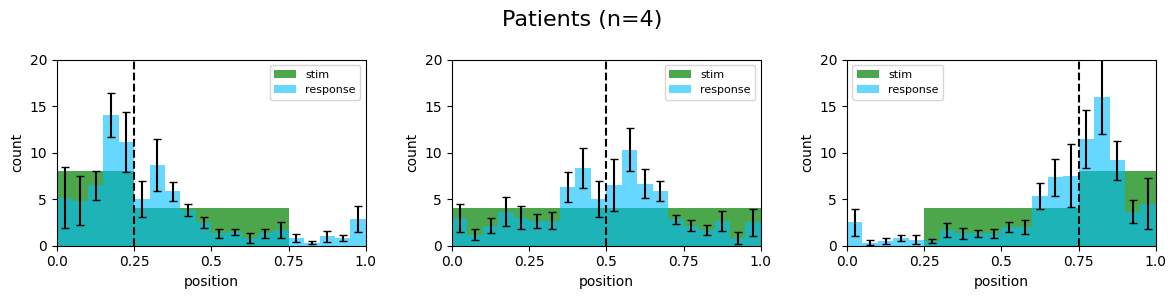

In [8]:

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs, ax = axs.flatten(), 0

ba_bins = np.linspace(-.4, .4, 21)
bar_centers = np.linspace(-.38, .38, 20)

for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered

    df_cond = df_analysis[df_analysis['condition'] == cond].copy()

    # true stim distribution per subj (stim_pos is already in -.4 to .4 space)
    stim_cts = []
    for subj, subj_df in df_cond.groupby('subj'):
        counts, _ = np.histogram(subj_df['stim_pos'], bins=ba_bins)
        stim_cts.append(counts)
    stim_cts = np.array(stim_cts)
    mean_stim_cts = stim_cts.mean(axis=0)

    # response distribution per subj
    resp_cts = []
    for subj, subj_df in df_cond.groupby('subj'):
        counts, _ = np.histogram(subj_df['chosen_pos_aligned'], bins=ba_bins)
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)
    mean_resp_cts = resp_cts.mean(axis=0)
    sem_resp_cts = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])

    # plot
    axs[ax].bar(bar_centers, mean_stim_cts, width=.04, color='green', alpha=0.7, label='stim')
    axs[ax].bar(bar_centers, mean_resp_cts, width=.04, color='deepskyblue',
                yerr=sem_resp_cts, capsize=3, label='response', alpha=0.6)

    axs[ax].set(xlabel='position', ylabel='count', xlim=(-.4, .4), ylim=(0,20),
                xticks=norm_ticks, xticklabels=norm_ticklabels)
    # boundary
    axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
    axs[ax].legend(fontsize=8)
    ax += 1

plt.suptitle(f'Patients (n=4)', fontsize=16)
plt.tight_layout()
plt.show()


## stim vs resp

### raw

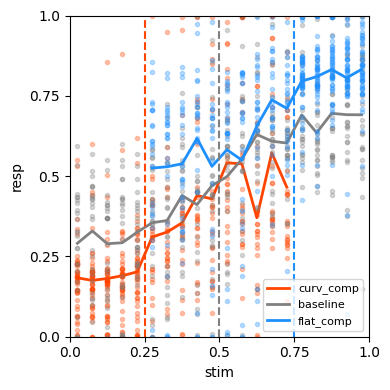

In [9]:
# plot stim vs resp, colored by condition
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}

# plot each condition
for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    ax.plot(df_cond['stim_pos'], df_cond['chosen_pos_aligned'], 'o', 
            markersize=3, alpha=0.3, color=colors[cond])
    
    # compute mean response per stim position
    mean_resp = df_cond.groupby('stim_pos')['chosen_pos_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, 
            label=cond, color=colors[cond])

# add identity line
# ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
ax.axvline(-0.2, color='orangered', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.axvline(0.2, color='dodgerblue', linestyle='--')

ax.set(xlabel='stim', ylabel='resp',
       xticks=norm_ticks, xticklabels=norm_ticklabels,
       yticks=norm_ticks, yticklabels=norm_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### boundary-aligned

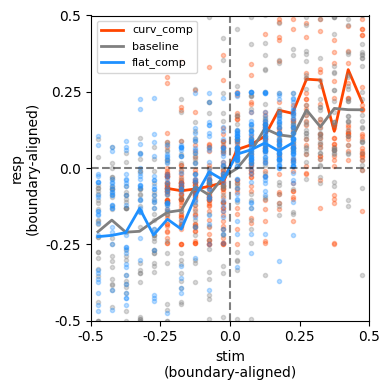

In [10]:

# plot stim vs resp, colored by condition
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}

# plot each condition
for cond in ['curv_comp', 'baseline', 'flat_comp']:
    
#     if cond == 'baseline': continue
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    ax.plot(df_cond['stim_aligned_to_div'], df_cond['resp_aligned_to_div'], 'o', 
            markersize=3, alpha=0.3, color=colors[cond])
    
    # compute mean response per stim position
    mean_resp = df_cond.groupby('stim_aligned_to_div')['resp_aligned_to_div'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, 
            label=cond, color=colors[cond])

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ba_ticklabels = np.linspace(-.5, .5, 5)
ax.set(xlabel='stim\n(boundary-aligned)', ylabel='resp\n(boundary-aligned)',
       xticks=norm_ticks, xticklabels=ba_ticklabels,
       yticks=norm_ticks, yticklabels=ba_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### rank-aligned

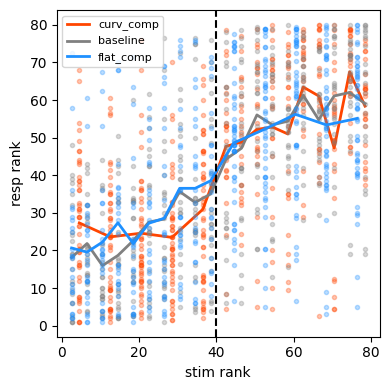

In [11]:
# plot stim vs resp, colored by condition
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}

# plot each condition
for cond in ['curv_comp', 'baseline', 'flat_comp']:
    df_cond = df_clean[df_clean['condition'] == cond].copy()
    ax.plot(df_cond['stim_ranks'], df_cond['resp_ranks'], 'o', 
            markersize=3, alpha=0.3, color=colors[cond])
    
    # compute mean response per stim position
    mean_resp = df_cond.groupby('stim_ranks')['resp_ranks'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, 
            label=cond, color=colors[cond])

ax.axvline(40, color='black', linestyle='--')
ax.set(xlabel='stim rank', ylabel='resp rank')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

interim summary: perception isn't objective, but aligned to context. The former can be seen visually, but the latter probably needs a statistical test.

### statistical test for alignment

### visualizing reflection of compressed conditions

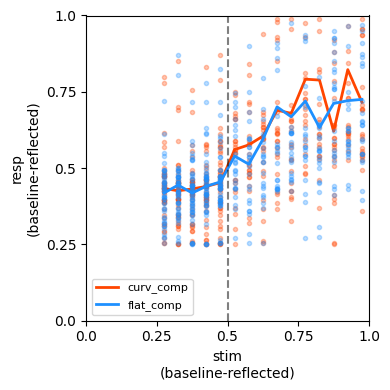

In [12]:
# plot stim vs resp, colored by condition
fig, ax = plt.subplots(1, 1, figsize=(4,4))
colors = {'curv_comp': 'orangered', 'baseline': 'gray', 'flat_comp': 'dodgerblue'}

# plot each condition
for cond in ['curv_comp', 'baseline', 'flat_comp']:
    
    if cond == 'baseline': continue
    df_cond = df_clean[df_clean['condition'] == cond].copy()

    if cond == 'flat_comp':
        df_cond['stim_aligned_to_div'] = -df_cond['stim_aligned_to_div']
        df_cond['resp_aligned_to_div'] = -df_cond['resp_aligned_to_div']
    
    ax.plot(df_cond['stim_aligned_to_div'], df_cond['resp_aligned_to_div'], 'o', 
            markersize=3, alpha=0.3, color=colors[cond])
    
    # compute mean response per stim position
    mean_resp = df_cond.groupby('stim_aligned_to_div')['resp_aligned_to_div'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, 
            label=cond, color=colors[cond])

# add identity line
# ax.plot([-.4, .4], [-.4, .4], 'k--', alpha=0.3)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set(xlabel='stim\n(baseline-reflected)', ylabel='resp\n(baseline-reflected)',
       xticks=norm_ticks, xticklabels=norm_ticklabels,
       yticks=norm_ticks, yticklabels=norm_ticklabels,
       xlim=(-.4, .4), ylim=(-.4, .4))

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# # groupby condition
# for cond in ['curv_comp', 'baseline', 'flat_comp']: # ordered
    
#     df_cond = df_clean[df_clean['condition'] == cond].copy()
    
#     axs[ax].plot(df_cond['stim_pos'], df_cond['resp_ranks'], 'o', markersize=3)
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     # axs[ax].axhline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
            
#     axs[ax].set(title=f'{cond}', xlabel='stim position', ylabel='response rank',
#                 xticks=norm_ticks, xticklabels=norm_ticklabels)
#     ax += 1

# plt.suptitle(f'STim vs Resp Rank', y=1.05)
# plt.show()

In [14]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# for cond in ['curv', 'base', 'flat']:

#     # get df condition
#     df_name, df_analysis = get_df(cond)

#     # compute abs. rank error
#     df_analysis['abs_rank_err'] = np.abs(df_analysis['resp_ranks'] - df_analysis['stim_ranks'])
#     # compute median abs. rank error
#     median_by_stim = df_analysis.groupby('stim_pos', as_index=False)['abs_rank_err'].median().sort_values('stim_pos')

#     axs[ax].scatter(df_analysis['stim_pos'], df_analysis['abs_rank_err'], alpha=0.5, s=20)
#     axs[ax].plot(median_by_stim['stim_pos'], median_by_stim['abs_rank_err'], color='crimson', lw=2)

#     axs[ax].axvline(df_analysis['div_pos_aligned'].iloc[0], color='black', linestyle='--')
#     axs[ax].set(title=df_name,
#                 xlabel='Stim. Pos.', xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels,
#                 ylabel='|Response Rank Err.|')
#     ax += 1

# plt.tight_layout()
# plt.show()